In [2]:
import sympy as sp
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [130]:
# np.random.seed(14)
x_1, x_2, x_3 = sp.Symbol('x_1'), sp.Symbol('x_2'), sp.Symbol('x_3')
X = [x_1, x_2, x_3]
f = 5*x_1**2 + 2*x_2**2 + 5*x_3**2 - 2*x_1*x_2 - 4*x_1*x_3 - 2*x_3 + 1
l = 0.01
e = 0.00001 
x0 = np.array([0, 0, 0])
res = []
while True:
    x_rand_i = np.random.randint(0, len(X))
    x1 = x0 - l*np.array([sp.diff(f, X[i]).subs(dict(zip(X, x0))) if i == x_rand_i else 0 for i in range(len(X))])
    print(l*np.array([sp.diff(f, X[i]).subs(dict(zip(X, x0))) if i == x_rand_i else 0  for i in range(len(X))]), sum([abs(_) for _ in (x1 - x0)]))
    res.append([x0, f.subs(dict(zip(X, x0)))])
    if sum([abs(_) for _ in (x1 - x0)]) < e and (f.subs(dict(zip(X, x1))) - f.subs(dict(zip(X, x0)))) < e:
        break
    x0 = x1
res

[0.0 0.0 -0.0200000000000000] 0.0200000000000000
[0.0 0.0 -0.0180000000000000] 0.0180000000000000
[-0.00152000000000000 0.0 0.0] 0.00152000000000000
[0.0 0.0 -0.0162608000000000] 0.0162608000000000
[-0.00201843200000000 0.0 0.0] 0.00201843200000000
[0.0 0.0 -0.0147154572800000] 0.0147154572800000
[0.0 -7.07686400000000e-5 0.0] 7.07686400000000e-5
[0.0 -6.79378944000000e-5 0.0] 6.79378944000000e-5
[-0.00240798122188800 0.0 0.0] 0.00240798122188800
[0.0 0.0 -0.0133402308008755] 0.0133402308008755
[0.0 -0.000113380003061760 0.0] 0.000113380003061760
[-0.00270305993179546 0.0 0.0] 0.00270305993179546
[0.0 0.0 -0.0121143301180598] 0.0121143301180598
[0.0 -0.000162906001575199 0.0] 0.000162906001575199
[0.0 0.0 -0.0109028971062538] 0.0109028971062538
[0.0 0.0 -0.00981260739562843] 0.00981260739562843
[-0.00374920544344510 0.0 0.0] 0.00374920544344510
[-0.00337428489910059 0.0 0.0] 0.00337428489910059
[-0.00303685640919053 0.0 0.0] 0.00303685640919053
[0.0 -0.000359596696546915 0.0] 0.0003595

[[array([0, 0, 0]), 1],
 [array([0.0, 0.0, 0.0200000000000000], dtype=object), 0.962000000000000],
 [array([0.0, 0.0, 0.0380000000000000], dtype=object), 0.931220000000000],
 [array([0.00152000000000000, 0.0, 0.0380000000000000], dtype=object),
  0.931000512000000],
 [array([0.00152000000000000, 0.0, 0.0542608000000000], dtype=object),
  0.905881218419200],
 [array([0.00353843200000000, 0.0, 0.0542608000000000], dtype=object),
  0.905494181984031],
 [array([0.00353843200000000, 0.0, 0.0689762572800000], dtype=object),
  0.884922437102878],
 [array([0.00353843200000000, 7.07686400000000e-5, 0.0689762572800000],
        dtype=object),
  0.884921946299238],
 [array([0.00353843200000000, 0.000138706534400000, 0.0689762572800000],
        dtype=object),
  0.884921493974603],
 [array([0.00594641322188800, 0.000138706534400000, 0.0689762572800000],
        dtype=object),
  0.884370648485932],
 [array([0.00594641322188800, 0.000138706534400000, 0.0823164880808755],
        dtype=object),
  0.8

In [19]:
np.random.seed(14)
np.random.randint(551)

344

In [275]:
def stohastic_gradient_descent(X, 
    Y,
    /,
    error: float=0.001,
    itteration: int=1000,
    describe: bool=False,
    nround: int=3,
    convergence: bool=False,
    random_state: int=14 ) -> str:
    np.random.seed(random_state)
    X = np.array(X)
    Y = np.array(Y)
    W0 = sp.Symbol('w0')
    W = sp.symbols(f'w1:{2 if len(X.shape) == 1 else X.shape[1]+1}')
    variables = list(map(str, np.hstack(['w0', W])))
    w0 = np.zeros(2 if len(X.shape) == 1 else X.shape[1]+1, dtype=int) 
    res = []
    i = 0
    while True:
        k = np.random.randint(X.shape[0])
        f = (W0+np.asarray(X[k]).flatten()@np.asarray(W).flatten()-Y[k])**2
        H = [[sp.diff(sp.diff(f, W[i]), W[j]).subs(dict(zip(W, w0))) for i in range(len(W))] for j in range(len(W))]
        S = np.array([sp.diff(f, W[i]).subs(dict(zip(variables, w0))) for i in range(len(W))])
        t = float(S@(S.T)/(S@H@(S.T)).subs(dict(zip(W, w0))))
        w1 = w0 - t*np.array([sp.diff(f, variables[i]).subs(dict(zip(variables, w0))) for i in range(len(variables))])
        res.append([[round(_, nround) for _ in w0], f.subs(dict(zip(variables, w0)))])
        if describe:
            print(f'Иттерация №{i} с шагом {t} в точке приближения {dict(zip(variables, res[-1][0]))} со значением {f.subs(dict(zip(variables, w0)))} и погрешностью {abs(sum(w1 - w0))}')
        if abs(sum(w1 - w0)) < error:
            if convergence:
                sns.pointplot(x=range(i+1), y=[float(_[1]) for _ in res])
                plt.grid()
            return f'Приблеженные значения точки минимума: {dict(zip(variables, res[-1][0]))} со значением {res[-1][1]}, с точностью {error}'
        w0 = w1
        i += 1
        if i > itteration:
            return f'Число иттераций превысило {itteration}'

In [276]:
np.random.seed(14)
X = X_test
Y = Y_test
W0 = sp.Symbol('w0')
W = sp.symbols(f'w1:{2 if len(X.shape) == 1 else X.shape[1]+1}')
k = np.random.randint(X.shape[0])
np.asarray(X[k]).flatten()@np.asarray(W).flatten()
f = (W0+np.asarray(X[k]).flatten()@np.asarray(W).flatten()-Y[k])**2
w0 = np.zeros(2 if len(X.shape) == 1 else X.shape[1]+1, dtype=int)
variables = list(map(str, np.hstack(['w0', W])))
H = [[sp.diff(sp.diff(f, W[i]), W[j]).subs(dict(zip(W, w0))) for i in range(len(W))] for j in range(len(W))]
S = np.array([sp.diff(f, W[i]).subs(dict(zip(variables, w0))) for i in range(len(W))])
t = float(S@(S.T)/(S@H@(S.T)).subs(dict(zip(W, w0))))
f, W,w0 , t*np.array([sp.diff(f, variables[i]).subs(dict(zip(variables, w0))) for i in range(len(variables))])

((w0 + 87.8775510204081*w1 - 1059.35027553357)**2,
 (w1,),
 array([0, 0]),
 array([-0.137177755595898, -12.0548452162436], dtype=object))

In [277]:
df = pd.read_csv('D:/ProjectPython/Анализ даных/Пакеты прикладных программ/FOOD-DATA-GROUP1 (1).csv').loc[:, 'Caloric Value':'Monounsaturated Fats']
df

,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats
0,51,5.0,2.900,1.300
1,215,19.4,10.900,4.900
2,49,3.6,2.300,0.900
3,30,2.0,1.300,0.500
4,30,2.3,1.400,0.600
...,...,...,...,...
546,159,5.9,1.300,2.800
547,50,3.4,0.500,1.600
548,33,0.3,0.049,0.006
549,147,1.3,0.300,0.400


In [278]:
stohastic_gradient_descent(df.loc[:, 'Caloric Value':'Saturated Fats'], np.array(df['Monounsaturated Fats']), describe=True)

Иттерация №0 с шагом 2.3440964867619496e-05 в точке приближения {'w0': np.int64(0), 'w1': np.int64(0), 'w2': np.int64(0), 'w3': np.int64(0)} со значением 1.21000000000000 и погрешностью 0.00780771657810670
Иттерация №1 с шагом 2.2716513360490166e-05 в точке приближения {'w0': 0.0, 'w1': 0.008, 'w2': 0.0, 'w3': 0.0} со значением 4.76818859543987 и погрешностью 0.0159923917604952
Иттерация №2 с шагом 1.650303358763408e-05 в точке приближения {'w0': 0.0, 'w1': 0.022, 'w2': 0.001, 'w3': 0.0} со значением 8.82499352739194 и погрешностью 0.0177079677747248
Иттерация №3 с шагом 2.230808355715777e-06 в точке приближения {'w0': 0.0, 'w1': 0.005, 'w2': 0.001, 'w3': 0.0} со значением 1.55912689051972 и погрешностью 0.00279106991195396
Иттерация №4 с шагом 1.3996451619585404e-05 в точке приближения {'w0': 0.0, 'w1': 0.008, 'w2': 0.001, 'w3': 0.0} со значением 1.62054973362671 и погрешностью 0.00683483016814984
Иттерация №5 с шагом 4.9879043319949124e-05 в точке приближения {'w0': 0.0, 'w1': 0.001,

"Приблеженные значения точки минимума: {'w0': 0.0, 'w1': 0.007, 'w2': 0.005, 'w3': 0.002} со значением 0.00139225776043354, с точностью 0.001"

In [212]:
X = np.array(df.loc[:, 'Caloric Value':'Saturated Fats'])
Y = np.array(df['Monounsaturated Fats'])
W0 = sp.Symbol('w0')
W = sp.symbols(f'w0:{0 if len(X.shape) == 1 else X.shape[1]}')
k = np.random.randint(X.shape[0])
f = (W0+X[k]@W-Y[k])**2
w0 = np.zeros(X.shape[1]+1, dtype=int)
variables = list(map(str, np.hstack(['w0', W])))
H = [[sp.diff(sp.diff(f, W[i]), W[j]).subs(dict(zip(W, w0))) for i in range(len(W))] for j in range(len(W))]
S = np.array([sp.diff(f, W[i]).subs(dict(zip(variables, w0))) for i in range(len(W))])
t = float(S@(S.T)/(S@H@(S.T)).subs(dict(zip(W, w0))))
f, W,w0 , t*np.array([sp.diff(f, variables[i]).subs(dict(zip(variables, w0))) for i in range(len(variables))])


((190.0*w0 + 1.5*w1 + 0.3*w2 - 0.2)**2,
 (w0, w1, w2),
 array([0, 0, 0, 0]),
 array([-0.00105256335184922, -0.00105256335184922, -8.30971067249381e-6,
        -1.66194213449876e-6], dtype=object))

In [31]:
X[1]@W

215.0*w1 + 19.4*w2 + 10.9*w3

In [138]:
X.shape

(551, 3)

In [200]:
((4,)[0], 0)

(4, 0)

In [33]:
Y[1]

np.float64(4.9)

In [35]:
(X[1]@W - Y[1])**2

(215.0*w1 + 19.4*w2 + 10.9*w3 - 4.9)**2

In [290]:
X_test = np.linspace(1, 100)
Y_test = 1000 + 12*X_test + np.random.normal(0,1)
Y_test

array([1011.21714897, 1035.46204693, 1059.70694489, 1083.95184285,
       1108.19674081, 1132.44163877, 1156.68653673, 1180.93143469,
       1205.17633265, 1229.42123061, 1253.66612856, 1277.91102652,
       1302.15592448, 1326.40082244, 1350.6457204 , 1374.89061836,
       1399.13551632, 1423.38041428, 1447.62531224, 1471.8702102 ,
       1496.11510816, 1520.36000612, 1544.60490407, 1568.84980203,
       1593.09469999, 1617.33959795, 1641.58449591, 1665.82939387,
       1690.07429183, 1714.31918979, 1738.56408775, 1762.80898571,
       1787.05388367, 1811.29878163, 1835.54367958, 1859.78857754,
       1884.0334755 , 1908.27837346, 1932.52327142, 1956.76816938,
       1981.01306734, 2005.2579653 , 2029.50286326, 2053.74776122,
       2077.99265918, 2102.23755714, 2126.48245509, 2150.72735305,
       2174.97225101, 2199.21714897])

<Axes: >

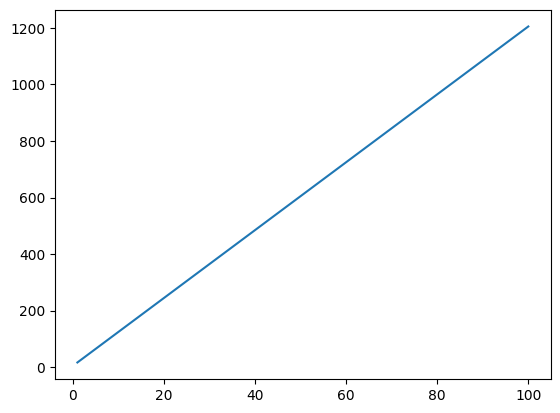

In [270]:
sns.lineplot(x=X_test, y=Y_test)

In [285]:
stohastic_gradient_descent(X_test, Y_test, error=0.0001, describe=True)

Иттерация №0 с шагом 6.474617450153808e-05 в точке приближения {'w0': np.int64(0), 'w1': np.int64(0)} со значением 4218697.62569585 и погрешностью 23.6387978998927
Иттерация №1 с шагом 0.0002041449675842279 в точке приближения {'w0': 0.266, 'w1': 23.373} со значением 190367.591030155 и погрешностью 8.99432956245969
Иттерация №2 с шагом 0.0007845538630046749 в точке приближения {'w0': 0.444, 'w1': 32.189} со значением 239416.916822402 и погрешностью 20.1500007303274
Иттерация №3 с шагом 0.00024205927619336436 в точке приближения {'w0': 1.212, 'w1': 51.571} со значением 640429.659869533 и погрешностью 17.9954877453750
Иттерация №4 с шагом 0.0021804912780348878 в точке приближения {'w0': 0.824, 'w1': 33.963} со значением 443564.524752474 и погрешностью 46.8859970049353
Иттерация №5 с шагом 8.26578808557394e-05 в точке приближения {'w0': 3.729, 'w1': 77.945} со значением 17083329.4126923 и погрешностью 53.8259551050138
Иттерация №6 с шагом 6.782926957566564e-05 в точке приближения {'w0': 3

"Приблеженные значения точки минимума: {'w0': 997.330, 'w1': 12.046} со значением 1.36833746815345E-7, с точностью 0.0001"

In [268]:
X_test.shape

(50,)

In [251]:
np.random.seed(14)
X = X_test
Y = Y_test
W0 = sp.Symbol('w0')
W = sp.symbols(f'w1:{2 if len(X.shape) == 1 else X.shape[1]+1}')
k = np.random.randint(X.shape[0])
np.asarray(X[k]).flatten()@np.asarray(W).flatten()
f = (W0+np.asarray(X[k]).flatten()@np.asarray(W).flatten()-Y[k])**2
w0 = np.zeros(2 if len(X.shape) == 1 else X.shape[1]+1, dtype=int)
variables = list(map(str, np.hstack(['w0', W])))
H = [[sp.diff(sp.diff(f, W[i]), W[j]).subs(dict(zip(W, w0))) for i in range(len(W))] for j in range(len(W))]
S = np.array([sp.diff(f, W[i]).subs(dict(zip(variables, w0))) for i in range(len(W))])
t = float(S@(S.T)/(S@H@(S.T)).subs(dict(zip(W, w0))))
f, W,w0 , t*np.array([sp.diff(f, variables[i]).subs(dict(zip(variables, w0))) for i in range(len(variables))])

((w0 + 87.8775510204081*w1 - 529.349766620161)**2,
 (w1,),
 array([0, 0]),
 array([-0.0685467447238748, -6.02372005675520], dtype=object))

In [230]:
2@(1,)

TypeError: unsupported operand type(s) for @: 'int' and 'tuple'

In [231]:
np.asarray(2).flatten() @ np.asarray((1,)).flatten()

np.int64(2)

In [227]:
np.array([1])@(1,)

np.int64(1)

In [228]:
1@(1,)

TypeError: unsupported operand type(s) for @: 'int' and 'tuple'